In [ ]:
!pip install -q catboost h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.0/266.0 MB 5.2 MB/s eta 0:00:00


# Data loading and statistics

In [ ]:
import kagglehub
path = kagglehub.dataset_download("saurav9786/real-time-advertisers-auction")
print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'real-time-advertisers-auction' dataset.
Dataset downloaded to: /kaggle/input/real-time-advertisers-auction


In [ ]:
import pandas as pd
import os
ad_data = pd.read_csv(os.path.join(path, "Dataset.csv"))

In [ ]:
print(f"\nFirst few rows:")
ad_data.head()


First few rows:


,date,site_id,ad_type_id,geo_id,device_category_id,advertiser_id,order_id,line_item_type_id,os_id,integration_type_id,monetization_channel_id,ad_unit_id,total_impressions,total_revenue,viewable_impressions,measurable_impressions,revenue_share_percent
0,2019-06-30 00:00:00,351,10,187,2,84,3473,19,60,1,4,5174,16,0.0,2,16,1
1,2019-06-30 00:00:00,351,10,187,2,84,3473,19,58,1,4,5174,6,0.0,0,6,1
2,2019-06-30 00:00:00,351,10,147,2,84,3473,19,60,1,4,5174,4,0.0,0,4,1
3,2019-06-30 00:00:00,351,10,147,2,84,3473,19,58,1,4,5174,4,0.0,0,4,1
4,2019-06-30 00:00:00,348,10,147,3,79,3463,20,59,1,19,5138,4,0.0,0,4,1


In [ ]:
# Data Overview
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total Records: {len(ad_data):,}")
print(f"Features: {ad_data.shape[1]}")
print(f"\nMissing Values per Column:")
print(ad_data.isnull().sum())
print(ad_data.dtypes)

DATASET SUMMARY
Total Records: 567,291
Features: 17

Missing Values per Column:
date                       0
site_id                    0
ad_type_id                 0
geo_id                     0
device_category_id         0
advertiser_id              0
order_id                   0
line_item_type_id          0
os_id                      0
integration_type_id        0
monetization_channel_id    0
ad_unit_id                 0
total_impressions          0
total_revenue              0
viewable_impressions       0
measurable_impressions     0
revenue_share_percent      0
dtype: int64
date                        object
site_id                      int64
ad_type_id                   int64
geo_id                       int64
device_category_id           int64
advertiser_id                int64
order_id                     int64
line_item_type_id            int64
os_id                        int64
integration_type_id          int64
monetization_channel_id      int64
ad_unit_id                   

# Feature Engineering

## Target Variable: CPM Calculation

CPM (Cost Per Mille) represents the revenue earned per 1,000 measurable impressions. We calculate it as:

$$
\text{CPM} = \frac{\text{total_revenue} \times 1000}{\text{measurable_impressions}}
$$


We use **measurable_impressions** instead of **total_impressions** because only measurable impressions can be reliably associated with valid viewability and revenue. This ensures the target variable reflects the monetizable portion of traffic.1

In [ ]:
def safe_division(n, d):
    """Safely divide, returning 0 if denominator is 0"""
    return n / d if d else 0

# Calculate CPM
ad_data['CPM'] = ad_data.apply(
    lambda x: safe_division((x['total_revenue'] * 100), x['measurable_impressions']) * 1000,
    axis=1
)

# Create derived feature: Viewability ratio (indicates ad quality)
ad_data['View_Measurable_Ratio'] = ad_data.apply(
    lambda x: safe_division(x['viewable_impressions'], x['measurable_impressions']),
    axis=1
)

# Convert date to timestamp for train/test split
ad_data['date'] = ad_data.date.apply(lambda l: pd.Timestamp(l).value)

print("CPM and derived features created")

CPM and derived features created


## Exploring the Zero-Inflation Problem

A critical challenge in ad monetization: most impressions don't generate revenue.

In [ ]:
# Analyze zero inflation
zero_cpm_count = (ad_data['CPM'] == 0).sum()
zero_cpm_pct = (zero_cpm_count / len(ad_data)) * 100

print("=" * 60)
print("ZERO-INFLATION ANALYSIS")
print("=" * 60)
print(f"Records with CPM = 0: {zero_cpm_count:,} ({zero_cpm_pct:.2f}%)")
print(f"Records with CPM > 0: {len(ad_data) - zero_cpm_count:,} ({100-zero_cpm_pct:.2f}%)")
print(f"\nCPM Statistics (All Data):")
print(ad_data['CPM'].describe())
print(f"\nCPM Statistics (Non-Zero Only):")
print(ad_data[ad_data['CPM'] > 0]['CPM'].describe())

ZERO-INFLATION ANALYSIS
Records with CPM = 0: 290,503 (56.61%)
Records with CPM > 0: 222,666 (43.39%)

CPM Statistics (All Data):
count    513169.000000
mean         93.629492
std         245.179464
min           0.000000
25%           0.000000
50%           0.000000
75%          80.000000
max        5730.000000
Name: CPM, dtype: float64

CPM Statistics (Non-Zero Only):
count    222666.000000
mean        215.783968
std         334.934470
min           0.588235
25%          30.000000
50%         103.333333
75%         216.875000
max        5730.000000
Name: CPM, dtype: float64


# Exploratory Data Analysis

In [ ]:
from prettytable import PrettyTable

impression_stats = PrettyTable()
impression_stats.field_names = ["Total","Viewable","Measurable"]
impression_stats.align[""] = "r"
impression_stats.add_row(["100%",
                          "%.2f"%((sum(ad_data['viewable_impressions'])/sum(ad_data['total_impressions']))*100),
                          "%.2f"%((sum(ad_data['measurable_impressions'])/sum(ad_data['total_impressions']))*100)])
print("Impression Report\n")
print(impression_stats)


Impression Report

+-------+----------+------------+
| Total | Viewable | Measurable |
+-------+----------+------------+
|  100% |  35.66   |   97.25    |
+-------+----------+------------+


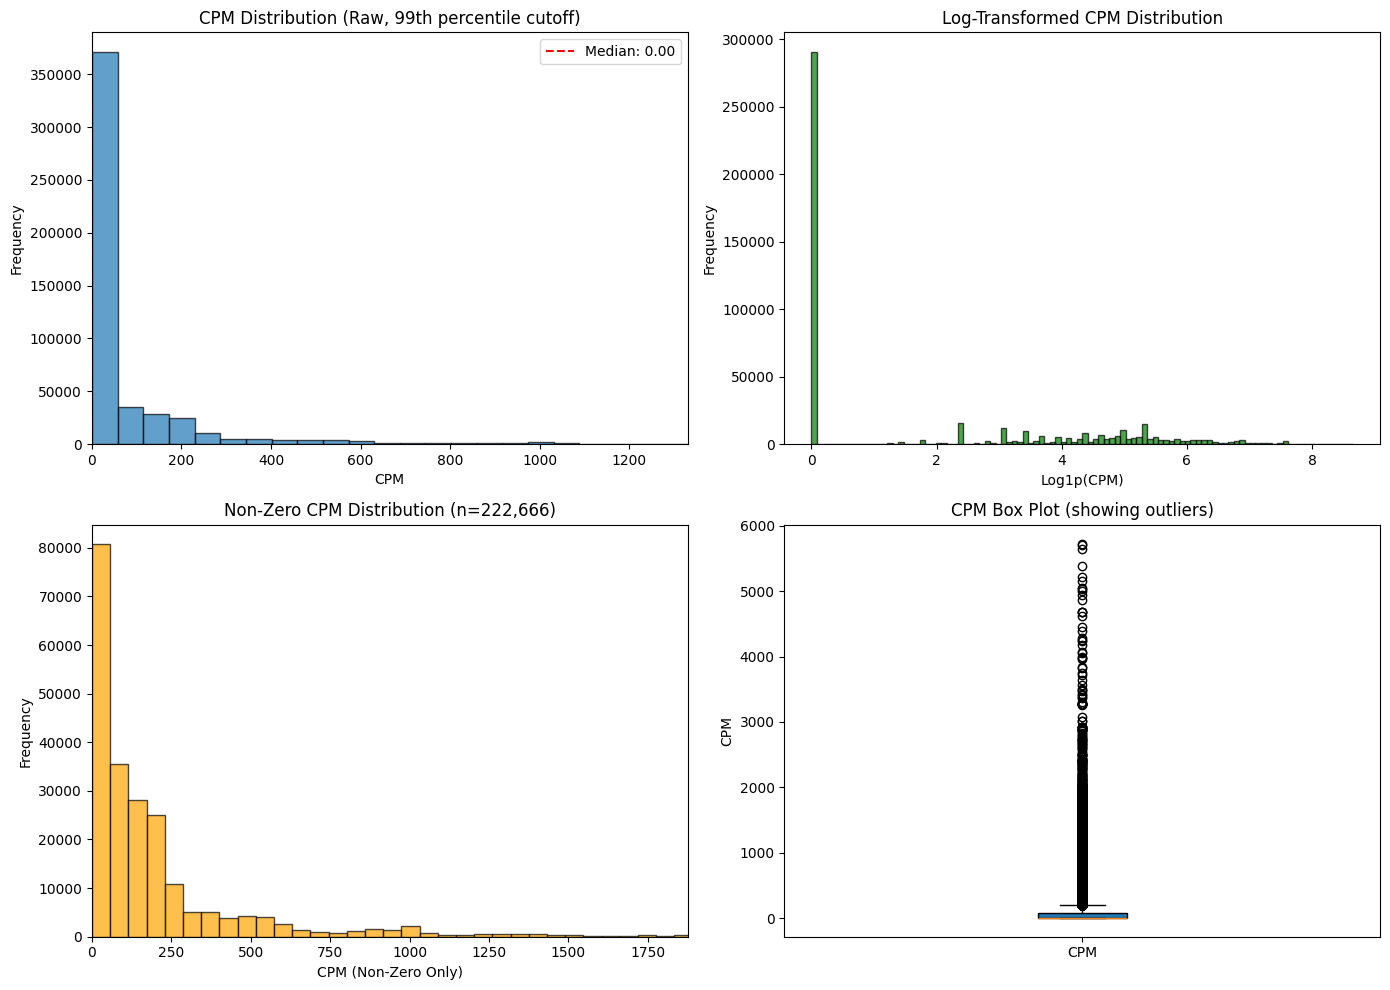


Observation: Severe zero-inflation (56.6%) and heavy right-skew detected
Justifies log-transform and two-stage modeling approach


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize CPM distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw CPM distribution (zoomed to 99th percentile)
axes[0, 0].hist(ad_data['CPM'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlim(0, ad_data['CPM'].quantile(0.99))
axes[0, 0].set_xlabel('CPM')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('CPM Distribution (Raw, 99th percentile cutoff)')
axes[0, 0].axvline(ad_data['CPM'].median(), color='red', linestyle='--',
                   label=f'Median: {ad_data["CPM"].median():.2f}')
axes[0, 0].legend()

# 2. Log1p CPM distribution
axes[0, 1].hist(np.log1p(ad_data['CPM']), bins=100, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Log1p(CPM)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Log-Transformed CPM Distribution')

# 3. Non-zero CPM only
nonzero_cpm = ad_data[ad_data['CPM'] > 0]['CPM']
axes[1, 0].hist(nonzero_cpm, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlim(0, nonzero_cpm.quantile(0.99))
axes[1, 0].set_xlabel('CPM (Non-Zero Only)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Non-Zero CPM Distribution (n={len(nonzero_cpm):,})')

# 4. Box plot
axes[1, 1].boxplot([ad_data['CPM']], vert=True, patch_artist=True)
axes[1, 1].set_ylabel('CPM')
axes[1, 1].set_title('CPM Box Plot (showing outliers)')
axes[1, 1].set_xticklabels(['CPM'])

plt.tight_layout()
plt.show()

zero_count = (ad_data['CPM'] == 0).sum()
total_count = len(ad_data)
zero_pct = zero_count / total_count

print(f"\nObservation: Severe zero-inflation ({zero_pct:.1%}) and heavy right-skew detected")
print(f"Justifies log-transform and two-stage modeling approach")

Categorical Feature Cardinality
site_id                       :     10 unique values
ad_type_id                    :      2 unique values
geo_id                        :    218 unique values
device_category_id            :      5 unique values
advertiser_id                 :     23 unique values
os_id                         :      7 unique values
monetization_channel_id       :      5 unique values
ad_unit_id                    :    132 unique values


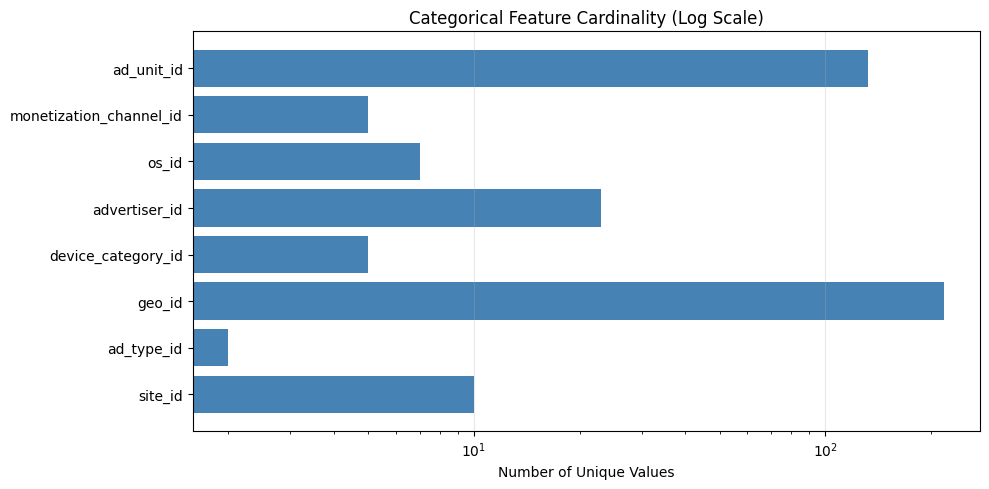

In [ ]:
# Analyze categorical feature cardinality
categorical_cols = ['site_id', 'ad_type_id', 'geo_id', 'device_category_id', 'advertiser_id',
                    'os_id', 'monetization_channel_id', 'ad_unit_id']

print("Categorical Feature Cardinality")
print("="*60)
cardinality_info = []
for col in categorical_cols:
    if col in ad_data.columns:
        n_unique = ad_data[col].nunique()
        cardinality_info.append({'Feature': col, 'Unique_Values': n_unique})
        print(f"{col:30s}: {n_unique:6d} unique values")

cardinality_df = pd.DataFrame(cardinality_info)

# Visualize cardinality
plt.figure(figsize=(10, 5))
plt.barh(cardinality_df['Feature'], cardinality_df['Unique_Values'], color='steelblue')
plt.xlabel('Number of Unique Values')
plt.title('Categorical Feature Cardinality (Log Scale)')
plt.xscale('log')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

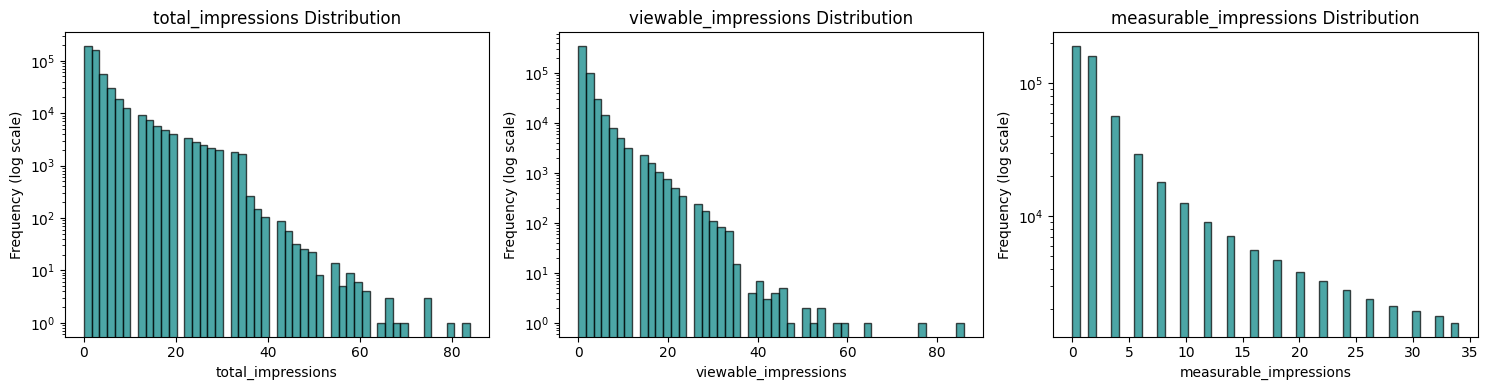


Numeric Feature Statistics
       total_impressions  viewable_impressions  measurable_impressions
count      513169.000000         513169.000000           513169.000000
mean            3.770473              1.344497                3.666928
std             6.015750              2.965516                5.784074
min             0.000000              0.000000                0.000000
25%             0.000000              0.000000                0.000000
50%             2.000000              0.000000                2.000000
75%             4.000000              2.000000                4.000000
max            84.000000             86.000000               34.000000


In [ ]:
# Analyze numeric features
numeric_cols = ['total_impressions', 'viewable_impressions', 'measurable_impressions']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_cols):
    if col in ad_data.columns:
        axes[i].hist(ad_data[col], bins=50, edgecolor='black', color='teal', alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency (log scale)')
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

print("\nNumeric Feature Statistics")
print("="*60)
print(ad_data[numeric_cols].describe())

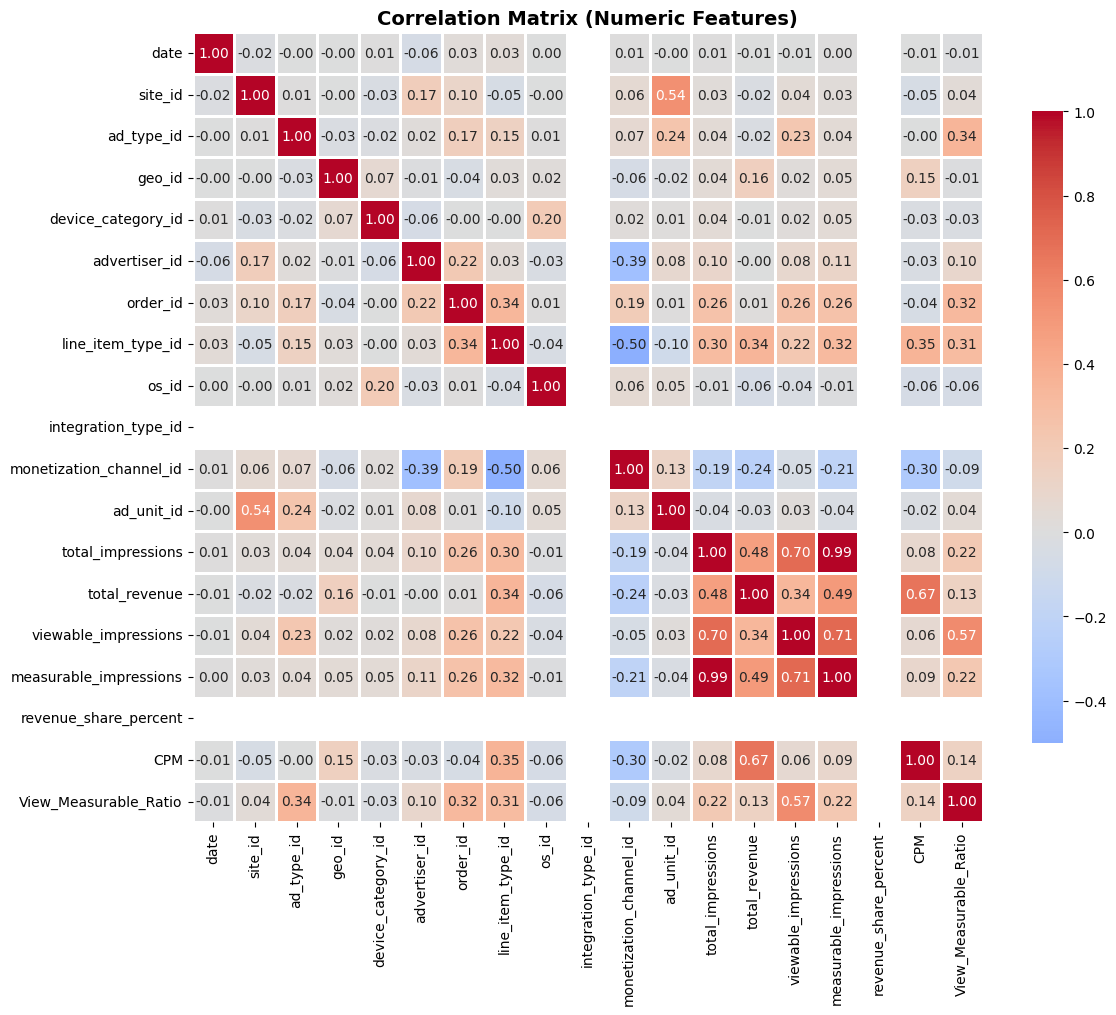


Highly Correlated Feature Pairs (|r| > 0.8)
        Feature_1              Feature_2 Correlation
total_impressions measurable_impressions       0.991

Note: total_impressions, viewable_impressions, measurable_impressions are highly correlated
This is expected as they measure the same concept. Retaining all features.


In [ ]:
import seaborn as sns

# Correlation matrix for numeric features
numeric_features = ad_data.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# High correlations
print("\nHighly Correlated Feature Pairs (|r| > 0.8)")
print("="*60)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': f"{corr_matrix.iloc[i, j]:.3f}"
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr)
    print(high_corr_df.to_string(index=False))
    print(f"\nNote: total_impressions, viewable_impressions, measurable_impressions are highly correlated")
    print(f"This is expected as they measure the same concept. Retaining all features.")
else:
    print("No pairs with |correlation| > 0.8 found.")

# Data Cleaning and Preprocessing

## Outlier Removal

We remove extreme outliers (CPM > 95th percentile) to improve model robustness. These represent less than 5% of data but can disproportionately affect model training.

In [ ]:
# Compute 95th percentile
cpm_95 = ad_data.CPM.quantile(.95)
print(f"95th Percentile CPM: {cpm_95:.2f}")

# Remove outliers
before_count = len(ad_data)
ad_data = ad_data[(ad_data.CPM >= 0) & (ad_data.CPM < cpm_95)]
ad_data.reset_index(inplace=True, drop=True)
after_count = len(ad_data)

print(f"Records before outlier removal: {before_count:,}")
print(f"Records after outlier removal: {after_count:,}")
print(f"Records removed: {before_count - after_count:,} ({((before_count - after_count)/before_count)*100:.2f}%)")

95th Percentile CPM: 526.92
Records before outlier removal: 567,291
Records after outlier removal: 538,924
Records removed: 28,367 (5.00%)


## Feature Selection

Based on domain knowledge and data analysis, we drop:
- **Constants:** `integration_type_id`, `revenue_share_percent` (only 1 unique value)
- **Non-informative:** `order_id`, `line_item_type_id` (as per problem specification)
- **Redundant:** `total_revenue` (already encoded in CPM)

In [ ]:
# Drop specified columns
cols_to_drop = ['integration_type_id', 'revenue_share_percent', 'order_id', 'line_item_type_id', 'total_revenue']
existing_cols_to_drop = [c for c in cols_to_drop if c in ad_data.columns]
ad_data.drop(columns=existing_cols_to_drop, inplace=True)

print(list(ad_data.columns))

['date', 'site_id', 'ad_type_id', 'geo_id', 'device_category_id', 'advertiser_id', 'os_id', 'monetization_channel_id', 'ad_unit_id', 'total_impressions', 'viewable_impressions', 'measurable_impressions', 'CPM', 'View_Measurable_Ratio']


## Feature Correlation Analysis

Understanding relationships between features helps identify multicollinearity and important predictors.

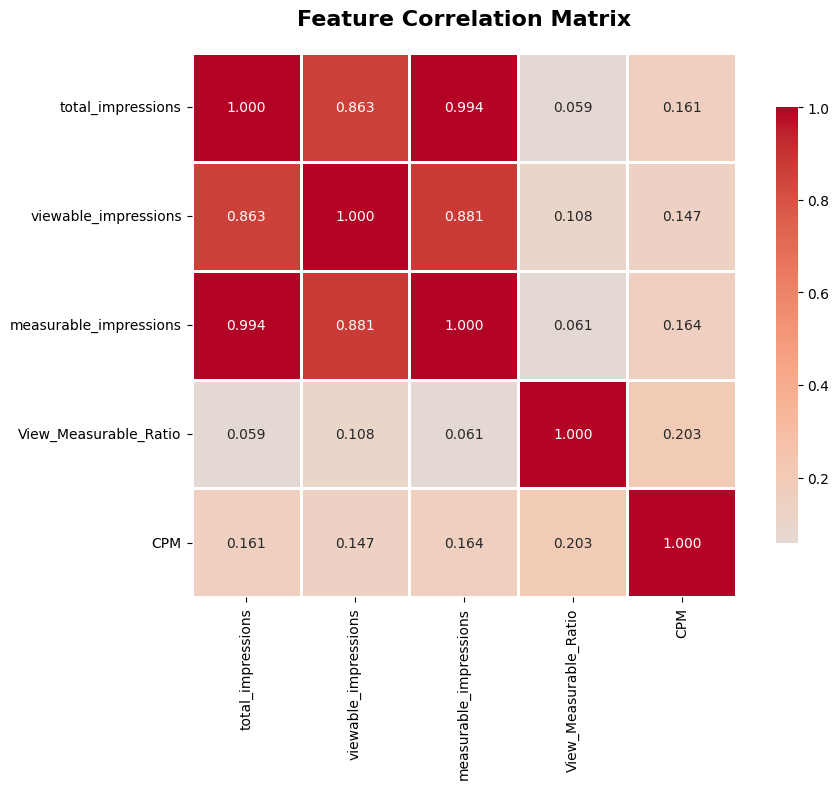

In [ ]:
import seaborn as sns

# Select numeric features for correlation
numeric_features = ['total_impressions', 'viewable_impressions', 'measurable_impressions',
                    'View_Measurable_Ratio', 'CPM']
corr_matrix = ad_data[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# The Inductive Bias



## Rationale for Why We Use L2 Loss and L2 Regularization

Although L1 loss treats all errors linearly, **L2 loss is more appropriate for CPM prediction because large errors are significantly more harmful than small ones**. For example, predicting a CPM of **0.4 instead of the true value 1.0** is far more damaging than predicting **0.9**. L2 loss captures this by **penalizing larger deviations quadratically**, aligning the optimization objective with real business impact.

In auction-based advertising systems, **underprediction is particularly risky**. If the model underestimates CPM, the bidding system submits bids that are too low, causing us to lose valuable impressions. Overestimation, in contrast, is usually less costly. Because CPM estimates often act as **lower bounds** for bidding decisions, pushing predictions toward the true upper range reduces missed opportunities. L2 loss naturally **emphasizes eliminating large negative deviations**.

---

# Inductive Bias: Why We Use L2 Loss and L2 Regularization

## Why L2 Loss?

A key reason for using **L2 loss** is that it implicitly assumes **Gaussian noise** in the data. Under a Gaussian error model, the maximum likelihood estimator corresponds exactly to minimizing squared error. This aligns naturally with CPM prediction, where we assume continuous-valued responses with symmetric, smooth noise characteristics.

The Gaussian assumption also supports the idea that **larger deviations are exponentially less likely** and therefore should be penalized more heavily. This matches the business reality: large underpredictions carry disproportionately higher cost in auction bidding environments.

In auction-based advertising systems, **underprediction is far more harmful than overprediction**:

* If the model **underestimates CPM**, the bid is too low → **we lose valuable impressions**.
* If the model **overestimates CPM**, we typically bid slightly higher than necessary → **less harmful**.

Because CPM predictions often act as **lower bounds** in downstream bidding logic, we need a loss function that strongly penalizes negative deviations.

**L2 loss (squared error)** provides:

* A **quadratic penalty**, meaning large underpredictions become disproportionately costly.
* A strong alignment with the business objective: **avoiding missed high-value auctions**.

## Why L2 (Ridge) Regularization?

L2 (ridge) regularization also carries a meaningful **Gaussian prior interpretation**. Mathematically, ridge regression is equivalent to assuming a **Gaussian prior over model coefficients**:

* The weights are assumed to come from a distribution **w ~ N(0, σ²I)**.
* This prior expresses the belief that coefficients should be **small, smooth, and evenly controlled**.
* The regularization term λ‖w‖² corresponds to the log-prior of this Gaussian distribution.

This Gaussian prior assumption stabilizes the optimization by shrinking weights in proportion to their magnitude, preventing any single coefficient from growing excessively—particularly important when features like *measurable impressions* and *viewable impressions* are highly collinear.

Many features in our dataset are strongly correlated, causing the matrix **XᵀX** to become ill-conditioned or even non-invertible. Ridge regularization, through its Gaussian prior, adds **λI** to XᵀX:

* Ensuring **invertibility**,
* Producing **stable**, well-behaved parameter estimates,
* Reducing variance while enabling better generalization.

Many features—such as *measurable impressions* and *viewable impressions*—are **highly collinear**. This causes:

* The matrix **XᵀX** to become **ill-conditioned** or even **non-invertible**.
* **High variance** and unstable coefficient estimates.

Ridge regularization adds **λI** to XᵀX:

* Ensures **invertibility**.
* Produces **stable**, well-behaved parameter estimates.
* Reduces overfitting.

## Summary: Why L2 + L2 Regularization?

Together, they give a model that:

* **Penalizes large underestimation errors** appropriately.
* **Remains robust** in the presence of strongly correlated predictors.
* **Generalizes well** under real auction conditions.

---

# Train-Test Split Strategy



## Time-Based Split (June 22, 2019)

We use a **temporal split** to simulate real-world deployment:
- **Training:** June 1-21, 2019
- **Testing:** June 22-30, 2019

This prevents **data leakage** and evaluates model performance on future data, as would occur in production.

In [ ]:
# Define Features and Target
cat_cols = ['measurable_impressions', 'site_id', 'ad_type_id', 'geo_id',
            'device_category_id', 'advertiser_id', 'os_id',
            'monetization_channel_id', 'ad_unit_id']
features = cat_cols + ['total_impressions', 'viewable_impressions']
target = 'CPM'

# Split Data (June 22, 2019)
split_date = pd.Timestamp('06-22-2019').value

train_df = ad_data.loc[ad_data.date < split_date].copy()
test_df = ad_data.loc[ad_data.date >= split_date].copy()

# Intelligent Missing Data Handling
# 1. Identify columns with missing values (in training set)
cols_with_missing = [col for col in train_df.columns if train_df[col].isnull().any()]

# 2. Add binary indicator variables
for col in cols_with_missing:
    train_df[f'{col}_is_missing'] = train_df[col].isnull().astype(int)
    test_df[f'{col}_is_missing'] = test_df[col].isnull().astype(int)
    # Add to features list if not already there (optional, but good practice)
    # features.append(f'{col}_is_missing')

# 3. Fill Missing Values (Imputation)
# For categorical/ID columns, 0 is often a reserved "unknown" ID, so filling with 0 is acceptable
# provided we have the indicator variable to capture the "missingness" signal.
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

print("=" * 60)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 60)
print(f"Training Set: {train_df.shape[0]:,} records ({(train_df.shape[0]/len(ad_data))*100:.1f}%)")
print(f"Test Set: {test_df.shape[0]:,} records ({(test_df.shape[0]/len(ad_data))*100:.1f}%)")
print(f"\nZero CPM in Training: {(train_df[target] == 0).sum():,} ({((train_df[target] == 0).sum()/len(train_df))*100:.1f}%)")
print(f"Zero CPM in Test: {(test_df[target] == 0).sum():,} ({((test_df[target] == 0).sum()/len(test_df))*100:.1f}%)")

TRAIN-TEST SPLIT SUMMARY
Training Set: 376,973 records (69.9%)
Test Set: 161,951 records (30.1%)

Zero CPM in Training: 209,084 (55.5%)
Zero CPM in Test: 87,589 (54.1%)


## Log Transformation

To handle the extreme right-skewness of CPM, we apply **log1p transformation**:

$$y_{\text{transformed}} = \log(1 + y)$$

Benefits:
1. Handles zeros gracefully (log(1+0) = 0)
2. Reduces impact of extreme outliers
3. Makes distribution more symmetric
4. Improves gradient-based optimization

In [ ]:
# Log Transformation of Target
y_train_log = np.log1p(train_df[target])
y_test_log = np.log1p(test_df[target])  # For H2O consistency
y_test_true = test_df[target]  # Keep original for evaluation

X_train = train_df[features].copy()
X_test = test_df[features].copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTarget Distribution (Log-Transformed):")
print(y_train_log.describe())

X_train shape: (376973, 11)
X_test shape: (161951, 11)

Target Distribution (Log-Transformed):
count    376973.000000
mean          1.923574
std           2.294944
min           0.000000
25%           0.000000
50%           0.000000
75%           4.394449
max           6.268860
Name: CPM, dtype: float64


# Evaluation Metrics


## We use three complementary metrics to evaluate model performance:

### 6.1 Root Mean Squared Error (RMSE)
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$
- **Primary metric** for overall prediction accuracy
- Penalizes large errors more heavily

### 6.2 Mean Absolute Percentage Error (MAPE)
$$MAPE = \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$$
- Captures **relative errors**, important for pricing decisions
- Scale-independent metric

### 6.3 Quantile Loss
$$L_\tau(y, \hat{y}) = \max(\tau(y - \hat{y}), (\tau - 1)(y - \hat{y}))$$
- Evaluates performance across revenue distribution
- Q10, Q50 (median), Q90 capture different market segments

**Important:** All metrics are computed on the **original scale** (after inverse log transformation) to ensure business interpretability.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

def quantile_loss(y_true, y_pred, quantile):
    """Calculate quantile loss for a given quantile."""
    residual = y_true - y_pred
    return np.maximum(quantile * residual, (quantile - 1) * residual).mean()

def evaluate_model(name, y_true, y_pred_log, verbose=True):
    """
    Evaluate model performance on original scale.

    Args:
        name: Model name
        y_true: True CPM values (original scale)
        y_pred_log: Predicted CPM values (log scale)
        verbose: Print results

    Returns:
        Dictionary of metrics
    """
    # Inverse transform predictions
    y_pred = np.expm1(y_pred_log)
    y_pred[y_pred < 0] = 0  # Ensure no negative predictions

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (only for non-zero true values)
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = 0.0

    # Quantile Losses
    q10 = quantile_loss(y_true, y_pred, 0.1)
    q50 = quantile_loss(y_true, y_pred, 0.5)
    q90 = quantile_loss(y_true, y_pred, 0.9)

    if verbose:
        print(f"\n{'='*60}")
        print(f"{name}")
        print(f"{'='*60}")
        print(f"RMSE:              {rmse:.4f}")
        print(f"MAPE:              {mape:.4f}%")
        print(f"Quantile Loss (Q10): {q10:.4f}")
        print(f"Quantile Loss (Q50): {q50:.4f}")
        print(f"Quantile Loss (Q90): {q90:.4f}")

    return {
        "Model": name,
        "RMSE": rmse,
        "MAPE": mape,
        "Q10": q10,
        "Q50": q50,
        "Q90": q90,
        "predictions": y_pred  # Store for later analysis
    }

results = []

# Custom Loss function

In [ ]:
# Alpha > 1.0 penalizes under-predictions (residuals < 0) more
def custom_asymmetric_loss(y_true, y_pred):
    residual = (y_true - y_pred).astype("float")
    grad = np.where(residual < 0, -2 * 2.5 * residual, -2 * residual)
    hess = np.where(residual < 0, 2 * 5.0, 2.0)
    return grad, hess

# Training

## Ridge Regression (Baseline)

**Why this model?**
- Establishes a **performance floor**
- Tests if linear relationships can predict CPM
- Fast to train and interpret

**Tuning:**
- We tune `alpha` (regularization strength). Higher alpha implies stronger regularization (simpler model).


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

def target_encode(train_df, test_df, col, target_col):
    global_mean = train_df[target_col].mean()
    agg = train_df.groupby(col)[target_col].mean()
    train_encoded = train_df[col].map(agg)
    test_encoded = test_df[col].map(agg)
    train_encoded.fillna(global_mean, inplace=True)
    test_encoded.fillna(global_mean, inplace=True)
    return train_encoded, test_encoded

# Prepare data for Ridge
X_train_ridge = X_train.copy()
X_test_ridge = X_test.copy()

temp_train = X_train_ridge.copy()
temp_train['target'] = y_train_log

print("Applying target encoding to categorical features...")
for col in cat_cols:
    train_enc, test_enc = target_encode(temp_train, X_test_ridge, col, 'target')
    X_train_ridge[col] = train_enc
    X_test_ridge[col] = test_enc

scaler = StandardScaler()
X_train_ridge_scaled = scaler.fit_transform(X_train_ridge)
X_test_ridge_scaled = scaler.transform(X_test_ridge)

print("\nTuning Ridge Regression...")
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
ridge_search = RandomizedSearchCV(ridge, ridge_params, n_iter=4, cv=3, scoring='neg_root_mean_squared_error', random_state=42)
ridge_search.fit(X_train_ridge_scaled, y_train_log)

print(f"Best Ridge Params: {ridge_search.best_params_}")
best_ridge = ridge_search.best_estimator_
pred_ridge_log = best_ridge.predict(X_test_ridge_scaled)

results.append(evaluate_model("Ridge Regression (Tuned)", y_test_true, pred_ridge_log))

Applying target encoding to categorical features...

Tuning Ridge Regression...
Best Ridge Params: {'alpha': 100.0}

Ridge Regression (Tuned)
RMSE:              93.7641
MAPE:              106.7157%
Quantile Loss (Q10): 8.1517
Quantile Loss (Q50): 21.3455
Quantile Loss (Q90): 34.5393


## h2o AutoML (Baseline)


**Why this model?**
- **Automated machine learning** that tests multiple algorithms
- Provides a strong baseline without manual hyperparameter tuning
- Includes stacked ensembles

H2O AutoML trains and cross-validates multiple models (GBM, XGBoost, GLM, Random Forest) and creates stacked ensembles.

In [ ]:
import h2o
from h2o.automl import H2OAutoML

print("Initializing H2O AutoML...")
try:
    h2o.init()

    train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train_log.rename(target)], axis=1))
    test_h2o = h2o.H2OFrame(X_test)

    # Train AutoML
    aml = H2OAutoML(max_models=10, seed=1, stopping_metric='MSE', nfolds=0)
    print("\nTraining H2O AutoML (this may take a few minutes)...")
    aml.train(x=features, y=target, training_frame=train_h2o)

    print("\n H2O AutoML Leaderboard (Top 10 Models):")
    print(aml.leaderboard.head(10))

    # Predict
    pred_h2o_log = aml.predict(test_h2o)
    pred_h2o_log_np = h2o.as_list(pred_h2o_log).values.flatten()

    results.append(evaluate_model("H2O AutoML", y_test_true, pred_h2o_log_np))

except Exception as e:
    print(f"H2O AutoML failed: {e}")
    print("Continuing with other models...")

Initializing H2O AutoML...
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.16" 2025-07-15; OpenJDK Runtime Environment (build 17.0.16+8-Ubuntu-0ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 17.0.16+8-Ubuntu-0ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpgh3x66us
  JVM stdout: /tmp/tmpgh3x66us/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpgh3x66us/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,6 days
H2O_cluster_name:,H2O_from_python_unknownUser_532tx1
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

Training H2O AutoML (this may take a few minutes)...
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%

 H2O AutoML Leaderboard (Top 10 Models):
model_id                               rmse      mse       mae       rmsle    mean_residual_deviance
XGBoost_2_AutoML_1_20251130_211809  1.12844  1.27339  0.661907  nan                          1.27339
GBM_1_AutoML_1_20251130_211809      1.13126  1.27974  0.674634    0.431526                   1.27974
XGBoost_1_AutoML_1_20251130_211809  1.13419  1.28639  0.654537  nan                          1.28639
GBM_4_AutoML_1_20251130_211809      1.13994  1.29947  0.688597    0.435609                   1.29947
XGBoost_3_AutoML_1_20251130_211809  1.14661  1.31471  0.701524  nan                          1.31471
GBM_3_AutoML_

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



H2O AutoML
RMSE:              75.0704
MAPE:              96.6892%
Quantile Loss (Q10): 9.5042
Quantile Loss (Q50): 16.6799
Quantile Loss (Q90): 23.8555


## Random Forest Regressor (bagging)

**Why this model?**
- **Ensemble of decision trees** reduces overfitting
- Handles mixed categorical/numeric features naturally
- Provides feature importance for interpretability

**Key Hyperparameters to Tune:**
- `n_estimators`: Number of trees. More is generally better but slower.
- `max_depth`: Controls tree complexity. Deeper trees capture more detail but risk overfitting.
- `min_samples_split`: Minimum samples required to split a node. Higher values prevent over-specific rules.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("Tuning Random Forest...")

# Define Parameter Grid
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Base Model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,  # Search 10 combinations
    cv=3,       # 3-fold Cross-Validation
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_ridge, y_train_log)

print(f"Best RF Params: {rf_search.best_params_}")

# Predict using Best Estimator
best_rf = rf_search.best_estimator_
pred_rf_log = best_rf.predict(X_test_ridge)

results.append(evaluate_model("Random Forest (Tuned)", y_test_true, pred_rf_log))

Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}

Random Forest (Tuned)
RMSE:              72.0264
MAPE:              98.2959%
Quantile Loss (Q10): 8.8851
Quantile Loss (Q50): 15.9527
Quantile Loss (Q90): 23.0203


## XGBoost (boosting)

**Why this model?**
- **Industry standard** for tabular data
- Gradient boosting with regularization (L1/L2)
- Handles missing values automatically

**Key Hyperparameters to Tune:**
- `learning_rate`: Step size shrinkage used in update to prevents overfitting.
- `max_depth`: Maximum depth of a tree.
- `subsample`: Subsample ratio of the training instances.
- `colsample_bytree`: Subsample ratio of columns when constructing each tree.

In [ ]:
import xgboost as xgb

print("Tuning XGBoost...")

# Define Parameter Grid
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

xgb_search = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train.values, y_train_log.values)

print(f"Best XGB Params: {xgb_search.best_params_}")

best_xgb = xgb_search.best_estimator_
pred_xgb_log = best_xgb.predict(X_test.values)

results.append(evaluate_model("XGBoost (Tuned)", y_test_true, pred_xgb_log))

Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

XGBoost (Tuned)
RMSE:              74.6758
MAPE:              93.5183%
Quantile Loss (Q10): 8.6212
Quantile Loss (Q50): 16.4501
Quantile Loss (Q90): 24.2789


## CatBoost

**Why this model?**
- **Best-in-class categorical feature handling**
- Built-in ordered target encoding
- Reduces overfitting on categorical features
- No explicit preprocessing needed

CatBoost uses ordered boosting and innovative categorical encoding techniques.

In [ ]:
from catboost import CatBoostRegressor

print("Training CatBoost...")
cat_model = CatBoostRegressor(
    iterations=500,
    cat_features=cat_cols,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train_log)
pred_cat_log = cat_model.predict(X_test)

results.append(evaluate_model("CatBoost", y_test_true, pred_cat_log))

Training CatBoost...

CatBoost
RMSE:              74.1296
MAPE:              97.4590%
Quantile Loss (Q10): 9.1489
Quantile Loss (Q50): 16.6131
Quantile Loss (Q90): 24.0773


## LightGBM

**Why this model?**
- **Faster than XGBoost** on large datasets
- Leaf-wise tree growth (vs level-wise)
- Native categorical feature support

**Key Hyperparameters to Tune:**
- `num_leaves`: Main parameter to control tree complexity.
- `min_child_samples`: Minimum number of data needed in a leaf. Prevent overfitting.
- `reg_alpha` / `reg_lambda`: L1/L2 regularization.

In [ ]:
import lightgbm as lgb

# Convert to categorical type for LightGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

print("Tuning LightGBM...")

lgb_params = {
    'n_estimators': [1000, 2000, 3000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0]
}

lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train_lgb, y_train_log)

print(f"Best LGB Params: {lgb_search.best_params_}")

best_lgb = lgb_search.best_estimator_
pred_lgb_log = best_lgb.predict(X_test_lgb)

results.append(evaluate_model("LightGBM (Tuned)", y_test_true, pred_lgb_log))

Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LGB Params: {'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 3000, 'min_child_samples': 50, 'learning_rate': 0.01}

LightGBM (Tuned)
RMSE:              72.9039
MAPE:              93.2754%
Quantile Loss (Q10): 8.7210
Quantile Loss (Q50): 16.1813
Quantile Loss (Q90): 23.6417


## LightGBM with Asymmetric Loss

**Why this model?**
Standard MSE treats over-prediction and under-prediction equally. In ad tech, under-predicting a winning bid price means losing the auction (opportunity cost), which is often worse than slightly over-paying. We use a custom asymmetric loss function to penalize under-predictions more heavily.

In [ ]:
print("Training LightGBM with Asymmetric Loss...")
lgb_asym = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    objective=custom_asymmetric_loss,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_asym.fit(
    X_train_lgb, y_train_log,
    eval_set=[(X_test_lgb, y_test_log)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False)
    ]
)

pred_lgb_asym_log = lgb_asym.predict(X_test_lgb)
results.append(evaluate_model("LightGBM (Asymmetric)", y_test_true, pred_lgb_asym_log))


Training LightGBM with Asymmetric Loss...

LightGBM (Asymmetric)
RMSE:              79.8851
MAPE:              78.7373%
Quantile Loss (Q10): 6.3654
Quantile Loss (Q50): 17.2313
Quantile Loss (Q90): 28.0972


## Two-stage Pipeline

**Why this model?**
The data is zero-inflated. We split the problem:
1.  **Classifier**: Predict Probability(CPM > 0). We tune an XGBoost Classifier for this.
2.  **Regressor**: Predict CPM value given CPM > 0. We use a LightGBM Regressor (using best params).
3.  **Combine**: Final Prediction = Probability * Regressor Prediction


In [ ]:
from xgboost import XGBClassifier

print("Training Two-Stage Pipeline...")

# Stage 1: Classifier (Zero vs Non-Zero)
print("Tuning Stage 1 Classifier...")
y_train_binary = (y_train_log > 0).astype(int)

clf_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

clf = XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=-1, eval_metric='logloss')
clf_search = RandomizedSearchCV(clf, clf_params, n_iter=4, cv=3, scoring='roc_auc', verbose=1, random_state=42)
clf_search.fit(X_train, y_train_binary)

print(f"Best Classifier Params: {clf_search.best_params_}")
best_clf = clf_search.best_estimator_
prob_test_nonzero = best_clf.predict_proba(X_test)[:, 1]

# Stage 2: Regressor
print("Training Stage 2 Regressor (using best LightGBM params)...")
mask_train_nonzero = y_train_log > 0
X_train_nonzero = X_train_lgb[mask_train_nonzero]
y_train_log_nonzero = y_train_log[mask_train_nonzero]

# Use best params from LGB search
stage2_params = lgb_search.best_params_


lgb_stage2 = lgb.LGBMRegressor(**stage2_params, random_state=42, n_jobs=-1, verbosity=-1)
lgb_stage2.fit(X_train_nonzero, y_train_log_nonzero)
pred_stage2_log = lgb_stage2.predict(X_test_lgb)

# Combine
pred_stage2_linear = np.expm1(pred_stage2_log)
pred_twostage_linear = prob_test_nonzero * pred_stage2_linear
pred_twostage_log = np.log1p(pred_twostage_linear)

results.append(evaluate_model("Two-Stage (Tuned)", y_test_true, pred_twostage_log))

Training Two-Stage Pipeline...
Tuning Stage 1 Classifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Classifier Params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Training Stage 2 Regressor (using best LightGBM params)...

Two-Stage (Tuned)
RMSE:              68.0271
MAPE:              102.4853%
Quantile Loss (Q10): 11.5397
Quantile Loss (Q50): 16.0530
Quantile Loss (Q90): 20.5663


**Why this model?**
The data is zero-inflated. We split the problem:
1. **Classifier**: Predict Probability(CPM > 0). We use a **LightGBM Classifier** for this.
2. **Regressor**: Predict CPM value given CPM > 0. We use a **LightGBM Regressor** (using best params).
3. **Combine**: Final Prediction = Probability * Regressor Prediction


In [ ]:
from lightgbm import LGBMClassifier

print("Training Two-Stage Pipeline (LightGBM Classifier)...")

# Stage 1: LightGBM Classifier (Zero vs Non-Zero)
print("Tuning Stage 1 LightGBM Classifier...")
y_train_binary = (y_train_log > 0).astype(int)

lgb_clf_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

lgb_clf = LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1)
lgb_clf_search = RandomizedSearchCV(lgb_clf, lgb_clf_params, n_iter=4, cv=3, scoring="roc_auc", verbose=1, random_state=42)
lgb_clf_search.fit(X_train_lgb, y_train_binary)

print(f"Best LightGBM Classifier Params: {lgb_clf_search.best_params_}")
best_lgb_clf = lgb_clf_search.best_estimator_
prob_test_nonzero_lgb = best_lgb_clf.predict_proba(X_test_lgb)[:, 1]

# Stage 2: Regressor (reuse from previous two-stage model)
print("Using Stage 2 Regressor from previous two-stage model...")
# We already have lgb_stage2 trained from cell 54
pred_stage2_log_lgb = lgb_stage2.predict(X_test_lgb)

# Combine
pred_stage2_linear_lgb = np.expm1(pred_stage2_log_lgb)
pred_twostage_lgb_linear = prob_test_nonzero_lgb * pred_stage2_linear_lgb
pred_twostage_lgb_log = np.log1p(pred_twostage_lgb_linear)

results.append(evaluate_model("Two-Stage (LGB+LGB)", y_test_true, pred_twostage_lgb_log))

Training Two-Stage Pipeline (LightGBM Classifier)...
Tuning Stage 1 LightGBM Classifier...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best LightGBM Classifier Params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Using Stage 2 Regressor from previous two-stage model...

Two-Stage (LGB+LGB)
RMSE:              67.8842
MAPE:              103.3747%
Quantile Loss (Q10): 11.5708
Quantile Loss (Q50): 15.9843
Quantile Loss (Q90): 20.3978


## Two-stage Pipeline with Asymmetric Loss

In [ ]:
print("Training Two-Stage Pipeline...")

# STAGE 1 — CLASSIFIER (Zero vs Non-Zero)
print("Stage 1: Training XGB Classifier...")

y_train_binary = (y_train_log > 0).astype(int)

clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

clf.fit(X_train, y_train_binary)

# P(CPM > 0)
prob_test_nonzero = clf.predict_proba(X_test)[:, 1]

# STAGE 2 — REGRESSOR (Only Non-Zero CPM)
print("Stage 2: Training LGB Regressor w/ Asymmetric Loss...")

mask_train_nonzero = y_train_log > 0
X_train_nonzero = X_train_lgb[mask_train_nonzero]
y_train_log_nonzero = y_train_log[mask_train_nonzero]

lgb_stage2 = lgb.LGBMRegressor(
    n_estimators=1000,       # full training, no early stopping
    learning_rate=0.05,
    objective=custom_asymmetric_loss,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_stage2.fit(X_train_nonzero, y_train_log_nonzero)

# Predict log-space CPM
pred_stage2_log = lgb_stage2.predict(X_test_lgb)

# COMBINE — Expected-Value CPM

print("Combining Predictions...")

# Convert Stage 2 to linear space
pred_stage2_linear = np.expm1(pred_stage2_log)

# Expected CPM = probability * regressor prediction
pred_twostage_linear = prob_test_nonzero * pred_stage2_linear

# Convert back to log for metric evaluation
pred_twostage_log = np.log1p(pred_twostage_linear)

results.append(
    evaluate_model("Two-Stage (XGB+LGB Asym)", y_test_true, pred_twostage_log)
)


Training Two-Stage Pipeline...
Stage 1: Training XGB Classifier...
Stage 2: Training LGB Regressor w/ Asymmetric Loss...
Combining Predictions...

Two-Stage (XGB+LGB Asym)
RMSE:              74.5290
MAPE:              79.1531%
Quantile Loss (Q10): 8.4345
Quantile Loss (Q50): 16.7307
Quantile Loss (Q90): 25.0268


In [ ]:
print("Training Two-Stage CPM Pipeline...")

# Stage 1 — Classifier P(CPM > 0)
print("Stage 1: LightGBM Classifier...")

y_train_binary = (y_train_log > 0).astype(int)

clf = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.04,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

clf.fit(X_train_lgb, y_train_binary)

# P(non-zero CPM)
prob_test_nonzero = clf.predict_proba(X_test_lgb)[:, 1]

# Stage 2 — Regressor trained ONLY on y > 0

print("Stage 2: LightGBM Asymmetric Regressor...")

mask = y_train_log > 0
X_train_nonzero = X_train_lgb[mask]
y_train_nonzero = y_train_log[mask]

lgb_stage2 = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=40,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective=custom_asymmetric_loss,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_stage2.fit(X_train_nonzero, y_train_nonzero)

pred_stage2_log = lgb_stage2.predict(X_test_lgb)

# 4) Combine — Expected CPM = P * f(x)

print("Combining Predictions...")

# Convert regressor output (log-space) → linear CPM
pred_stage2_linear = np.expm1(pred_stage2_log)

# Expected value: P(non-zero) * conditional prediction
pred_final_linear = prob_test_nonzero * pred_stage2_linear

# Convert back to log for evaluation
pred_final_log = np.log1p(pred_final_linear)

results.append(
    evaluate_model("Two-Stage (LGB+LGB Asym)", y_test_true, pred_final_log)
)


Training Two-Stage CPM Pipeline...
Stage 1: LightGBM Classifier...
Stage 2: LightGBM Asymmetric Regressor...
Combining Predictions...

Two-Stage (LGB+LGB Asym)
RMSE:              73.4158
MAPE:              80.0657%
Quantile Loss (Q10): 8.4302
Quantile Loss (Q50): 16.4388
Quantile Loss (Q90): 24.4474


In [ ]:
for idx in sorted([9, 10, 11, 12], reverse=True):
    del results[idx]


In [ ]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.drop('predictions', axis=1)

# Normalize RMSE, MAPE, and Q50 to same scale and sum them
results_df['balance_score'] = (
    (results_df['RMSE'] / results_df['RMSE'].max()) +
    (results_df['MAPE'] / results_df['MAPE'].max()) +
    (results_df['Q50'] / results_df['Q50'].max())
)

# Sort by balance_score first, then by RMSE as tie-breaker
results_df_sorted = results_df.sort_values(by=['balance_score', 'RMSE'])

# Print
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df_sorted.drop('balance_score', axis=1).to_string(index=False))
print("="*80)

# Highlight best performers individually
print("\nBEST PERFORMERS:")
print(f"Best Balanced: {results_df_sorted.iloc[0]['Model']}")
print(f"Best RMSE:  {results_df.loc[results_df['RMSE'].idxmin()]['Model']} ({results_df['RMSE'].min():.4f})")
print(f"Best MAPE:  {results_df.loc[results_df['MAPE'].idxmin()]['Model']} ({results_df['MAPE'].min():.4f}%)")
print(f"Best Q50:   {results_df.loc[results_df['Q50'].idxmin()]['Model']} ({results_df['Q50'].min():.4f})")


MODEL COMPARISON
                   Model      RMSE       MAPE       Q10       Q50       Q90
Two-Stage (LGB+LGB Asym) 73.415797  80.065694  8.430153 16.438796 24.447438
Two-Stage (XGB+LGB Asym) 74.528952  79.153114  8.434549 16.730681 25.026812
   LightGBM (Asymmetric) 79.885053  78.737303  6.365358 17.231283 28.097207
        LightGBM (Tuned) 72.903948  93.275442  8.721017 16.181350 23.641683
   Random Forest (Tuned) 72.026435  98.295885  8.885138 15.952727 23.020316
       Two-Stage (Tuned) 68.027067 102.485339 11.539748 16.053047 20.566346
     Two-Stage (LGB+LGB) 67.884234 103.374746 11.570775 15.984303 20.397830
         XGBoost (Tuned) 74.675795  93.518323  8.621249 16.450058 24.278866
                CatBoost 74.129648  97.459019  9.148950 16.613145 24.077340
              H2O AutoML 75.070371  96.689153  9.504222 16.679850 23.855478
Ridge Regression (Tuned) 93.764110 106.715695  8.151681 21.345469 34.539258

BEST PERFORMERS:
Best Balanced: Two-Stage (LGB+LGB Asym)
Best RMSE:  

CONFUSION MATRIX: Two-Stage LightGBM Classifier (Best Model)

Classification Report:
              precision    recall  f1-score   support

    Zero CPM       0.93      0.89      0.91     87589
Non-Zero CPM       0.88      0.92      0.90     74362

    accuracy                           0.90    161951
   macro avg       0.90      0.90      0.90    161951
weighted avg       0.90      0.90      0.90    161951



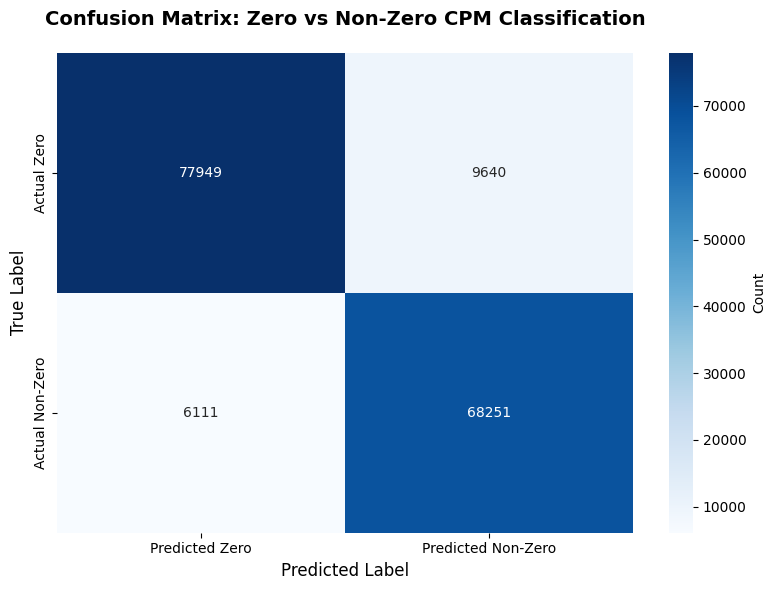


Key Metrics:
True Negatives (correctly predicted zero):  77,949
False Positives (predicted non-zero, was zero): 9,640
False Negatives (predicted zero, was non-zero): 6,111
True Positives (correctly predicted non-zero): 68,251

Accuracy: 0.9027
Precision (Non-Zero): 0.8762
Recall (Non-Zero): 0.9178


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("="*80)
print("CONFUSION MATRIX: Two-Stage LightGBM Classifier (Best Model)")
print("="*80)

# Get predictions from best two-stage classifier (from cell 59)
y_test_binary = (y_test_log > 0).astype(int)
y_pred_binary = (prob_test_nonzero > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary,
                           target_names=['Zero CPM', 'Non-Zero CPM']))

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Zero', 'Predicted Non-Zero'],
            yticklabels=['Actual Zero', 'Actual Non-Zero'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix: Zero vs Non-Zero CPM Classification',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate key metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nKey Metrics:")
print(f"True Negatives (correctly predicted zero):  {tn:,}")
print(f"False Positives (predicted non-zero, was zero): {fp:,}")
print(f"False Negatives (predicted zero, was non-zero): {fn:,}")
print(f"True Positives (correctly predicted non-zero): {tp:,}")
print(f"\nAccuracy: {(tn + tp) / (tn + fp + fn + tp):.4f}")
print(f"Precision (Non-Zero): {tp / (tp + fp):.4f}")
print(f"Recall (Non-Zero): {tp / (tp + fn):.4f}")

In [ ]:
from scipy import stats

def diebold_mariano_test(errors1, errors2, h=1):
    """
    Diebold-Mariano test for comparing forecast accuracy.

    Args:
        errors1: Forecast errors from model 1 (y_true - y_pred_1)
        errors2: Forecast errors from model 2 (y_true - y_pred_2)
        h: Forecast horizon (default 1 for one-step ahead)

    Returns:
        DM statistic and p-value
    """
    # Squared errors (MSE loss)
    d = errors1**2 - errors2**2

    # Mean difference
    mean_d = np.mean(d)

    # Variance of difference
    var_d = np.var(d, ddof=1)

    # DM statistic
    n = len(d)
    dm_stat = mean_d / np.sqrt(var_d / n)

    # Two-tailed p-value
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTING (Diebold-Mariano Test)")
print("="*80)

# Get predictions from results
results_full = pd.DataFrame(results)

# Select top 4 models by balance_score
top_models = results_df_sorted.head(4)['Model'].tolist()
print(f"\nComparing top 4 models:")
for i, model in enumerate(top_models, 1):
    print(f"{i}. {model}")

# Create comparison matrix
print("\n" + "="*80)
print("PAIRWISE COMPARISONS")
print("="*80)
print("DM Statistic > 0: Model 1 has larger errors (Model 2 is better)")
print("DM Statistic < 0: Model 2 has larger errors (Model 1 is better)")
print("p-value < 0.05: Difference is statistically significant\n")

comparison_results = []

for i, model1 in enumerate(top_models):
    for j, model2 in enumerate(top_models):
        if i < j:  # Only upper triangle
            # Get predictions
            pred1 = results_full[results_full['Model'] == model1]['predictions'].values[0]
            pred2 = results_full[results_full['Model'] == model2]['predictions'].values[0]

            # Calculate errors
            errors1 = y_test_true.values - pred1
            errors2 = y_test_true.values - pred2

            # Perform test
            dm_stat, p_value = diebold_mariano_test(errors1, errors2)

            # Interpret
            significant = "Yes" if p_value < 0.05 else "No"
            better = model2 if dm_stat > 0 else model1

            comparison_results.append({
                'Model 1': model1,
                'Model 2': model2,
                'DM Stat': f"{dm_stat:.4f}",
                'p-value': f"{p_value:.4f}",
                'Significant': significant,
                'Better Model': better if significant == "Yes" else "No difference"
            })

# Display results
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

sig_comparisons = comparison_df[comparison_df['Significant'] == 'Yes']
if len(sig_comparisons) > 0:
    print(f"\nFound {len(sig_comparisons)} statistically significant differences (p < 0.05):")
    for idx, row in sig_comparisons.iterrows():
        print(f"  • {row['Better Model']} significantly outperforms the alternative")
        print(f"    (DM = {row['DM Stat']}, p = {row['p-value']})")
else:
    print("\nNo statistically significant differences found among top models.")
    print("All models perform similarly from a statistical perspective.")

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
best_model = results_df_sorted.iloc[0]['Model']
best_rmse = results_df_sorted.iloc[0]['RMSE']
best_mape = results_df_sorted.iloc[0]['MAPE']
print(f"\nBased on balanced performance across RMSE, MAPE, and Q50:")
print(f"→ Recommended Model: {best_model}")
print(f"  RMSE: {best_rmse:.4f} | MAPE: {best_mape:.4f}%")

STATISTICAL SIGNIFICANCE TESTING (Diebold-Mariano Test)

Comparing top 4 models:
1. Two-Stage (LGB+LGB Asym)
2. Two-Stage (XGB+LGB Asym)
3. LightGBM (Asymmetric)
4. LightGBM (Tuned)

PAIRWISE COMPARISONS
DM Statistic > 0: Model 1 has larger errors (Model 2 is better)
DM Statistic < 0: Model 2 has larger errors (Model 1 is better)
p-value < 0.05: Difference is statistically significant

                 Model 1                  Model 2  DM Stat p-value Significant             Better Model
Two-Stage (LGB+LGB Asym) Two-Stage (XGB+LGB Asym) -31.8210  0.0000         Yes Two-Stage (LGB+LGB Asym)
Two-Stage (LGB+LGB Asym)    LightGBM (Asymmetric) -65.9334  0.0000         Yes Two-Stage (LGB+LGB Asym)
Two-Stage (LGB+LGB Asym)         LightGBM (Tuned)   6.0750  0.0000         Yes         LightGBM (Tuned)
Two-Stage (XGB+LGB Asym)    LightGBM (Asymmetric) -60.2407  0.0000         Yes Two-Stage (XGB+LGB Asym)
Two-Stage (XGB+LGB Asym)         LightGBM (Tuned)  18.4402  0.0000         Yes         Ligh